In [34]:
# 必要なライブラリをインポート
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import warnings
warnings.filterwarnings('ignore')

# 日本語表示のための設定 (japanize_matplotlib)
import japanize_matplotlib

# --- 1. データの読み込み ---
features_data_path = '../data/processed/features.parquet'
df = pd.read_parquet(features_data_path)

In [35]:
df.columns

Index(['市区町村コード', '都道府県名', '市区町村名', '地区名', '最寄駅：名称', '最寄駅：距離（分）', '間取り',
       '面積（㎡）', '建築年', '建物の構造', '用途', '今後の利用目的', '都市計画', '建ぺい率（％）', '容積率（％）',
       '取引時点', '取引価格（総額）_log', '取引時点での築年数', '取引の事情等_その他事情有り',
       '取引の事情等_他の権利・負担付き', '取引の事情等_他の権利・負担付き、調停・競売等', '取引の事情等_瑕疵有りの可能性',
       '取引の事情等_調停・競売等', '取引の事情等_調停・競売等、瑕疵有りの可能性', '取引の事情等_関係者間取引',
       '取引の事情等_関係者間取引、瑕疵有りの可能性', '取引の事情等_関係者間取引、調停・競売等', '取引の事情等_その他',
       '改装_改装済', '改装_未改装', '間取り_grouped_その他', '間取り_grouped_オープンフロア',
       '間取り_grouped_欠損値', '間取り_grouped_１ＤＫ', '間取り_grouped_１Ｋ',
       '間取り_grouped_１ＬＤＫ', '間取り_grouped_１Ｒ', '間取り_grouped_２ＤＫ',
       '間取り_grouped_２Ｋ', '間取り_grouped_２ＬＤＫ', '間取り_grouped_２ＬＤＫ＋Ｓ',
       '間取り_grouped_３ＤＫ', '間取り_grouped_３ＬＤＫ', '間取り_grouped_４ＤＫ',
       '間取り_grouped_４ＬＤＫ', '築年数_2乗', '築年数_3乗', '築年数_log', '面積_log', '面積_平方根',
       '築年数×面積', '築年数×駅距離', '築年数×建ぺい率', '築年数×容積率', '人口密度', '市区町村人口密度',
       '築年数×人口密度', '面積×駅距離', '面積×建ぺい率', '面積×容積率', '面積×人口密度', '建築可能性',
       '容積率_建ぺい率比', '建ぺい率_2乗'

# 最適クラスタ数について

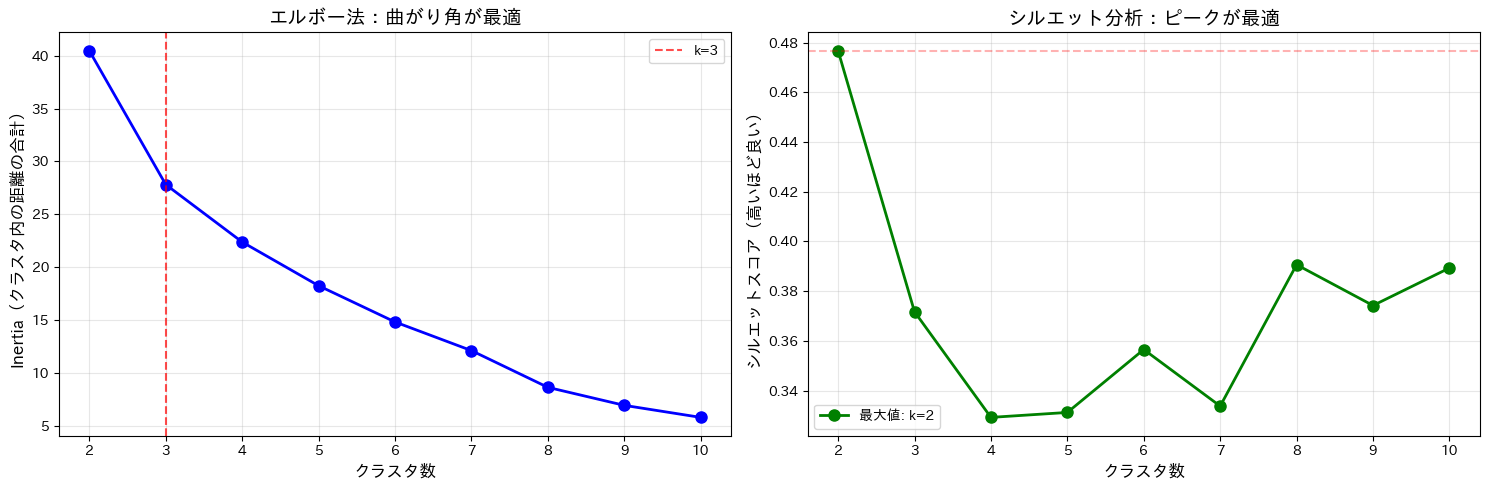

最適クラスタ数の判定結果
k=2: Inertia=40.46, シルエットスコア=0.477
k=3: Inertia=27.82, シルエットスコア=0.372
k=4: Inertia=22.39, シルエットスコア=0.329
k=5: Inertia=18.26, シルエットスコア=0.331
k=6: Inertia=14.84, シルエットスコア=0.357
k=7: Inertia=12.13, シルエットスコア=0.334
k=8: Inertia=8.66, シルエットスコア=0.391
k=9: Inertia=6.96, シルエットスコア=0.374
k=10: Inertia=5.82, シルエットスコア=0.389

📊 推奨クラスタ数
✓ シルエットスコアが最大: k=2 (スコア=0.477)
✓ エルボー法の目視判定: k=2〜3あたりで曲がり角

各クラスタ数での都道府県グルーピング

【k=2の場合】

クラスタ 0 (25都道府県, 482,763件):
  三重県, 京都府, 佐賀県, 兵庫県, 千葉県, 和歌山県, 埼玉県, 大阪府, 奈良県, 宮城県, 山口県, 山形県, 岐阜県, 岡山県, 島根県, 広島県, 愛知県, 東京都, 沖縄県, 滋賀県, 神奈川県, 長崎県, 長野県, 高知県, 鳥取県
  価格平均=7.13, 標準偏差=0.31

クラスタ 1 (22都道府県, 68,882件):
  北海道, 大分県, 宮崎県, 富山県, 山梨県, 岩手県, 徳島県, 愛媛県, 新潟県, 栃木県, 熊本県, 石川県, 福井県, 福岡県, 福島県, 秋田県, 群馬県, 茨城県, 青森県, 静岡県, 香川県, 鹿児島県
  価格平均=6.98, 標準偏差=0.40

【k=3の場合】

クラスタ 0 (14都道府県, 18,626件):
  大分県, 宮崎県, 山梨県, 徳島県, 愛媛県, 新潟県, 栃木県, 熊本県, 石川県, 福井県, 秋田県, 群馬県, 静岡県, 香川県
  価格平均=6.96, 標準偏差=0.41

クラスタ 1 (15都道府県, 461,074件):
  三重県, 京都府, 兵庫県, 千葉県, 埼玉県, 大阪府, 岐阜県, 島根県, 愛知県, 東京都, 沖縄県, 滋賀県, 神奈川県, 長崎県, 長

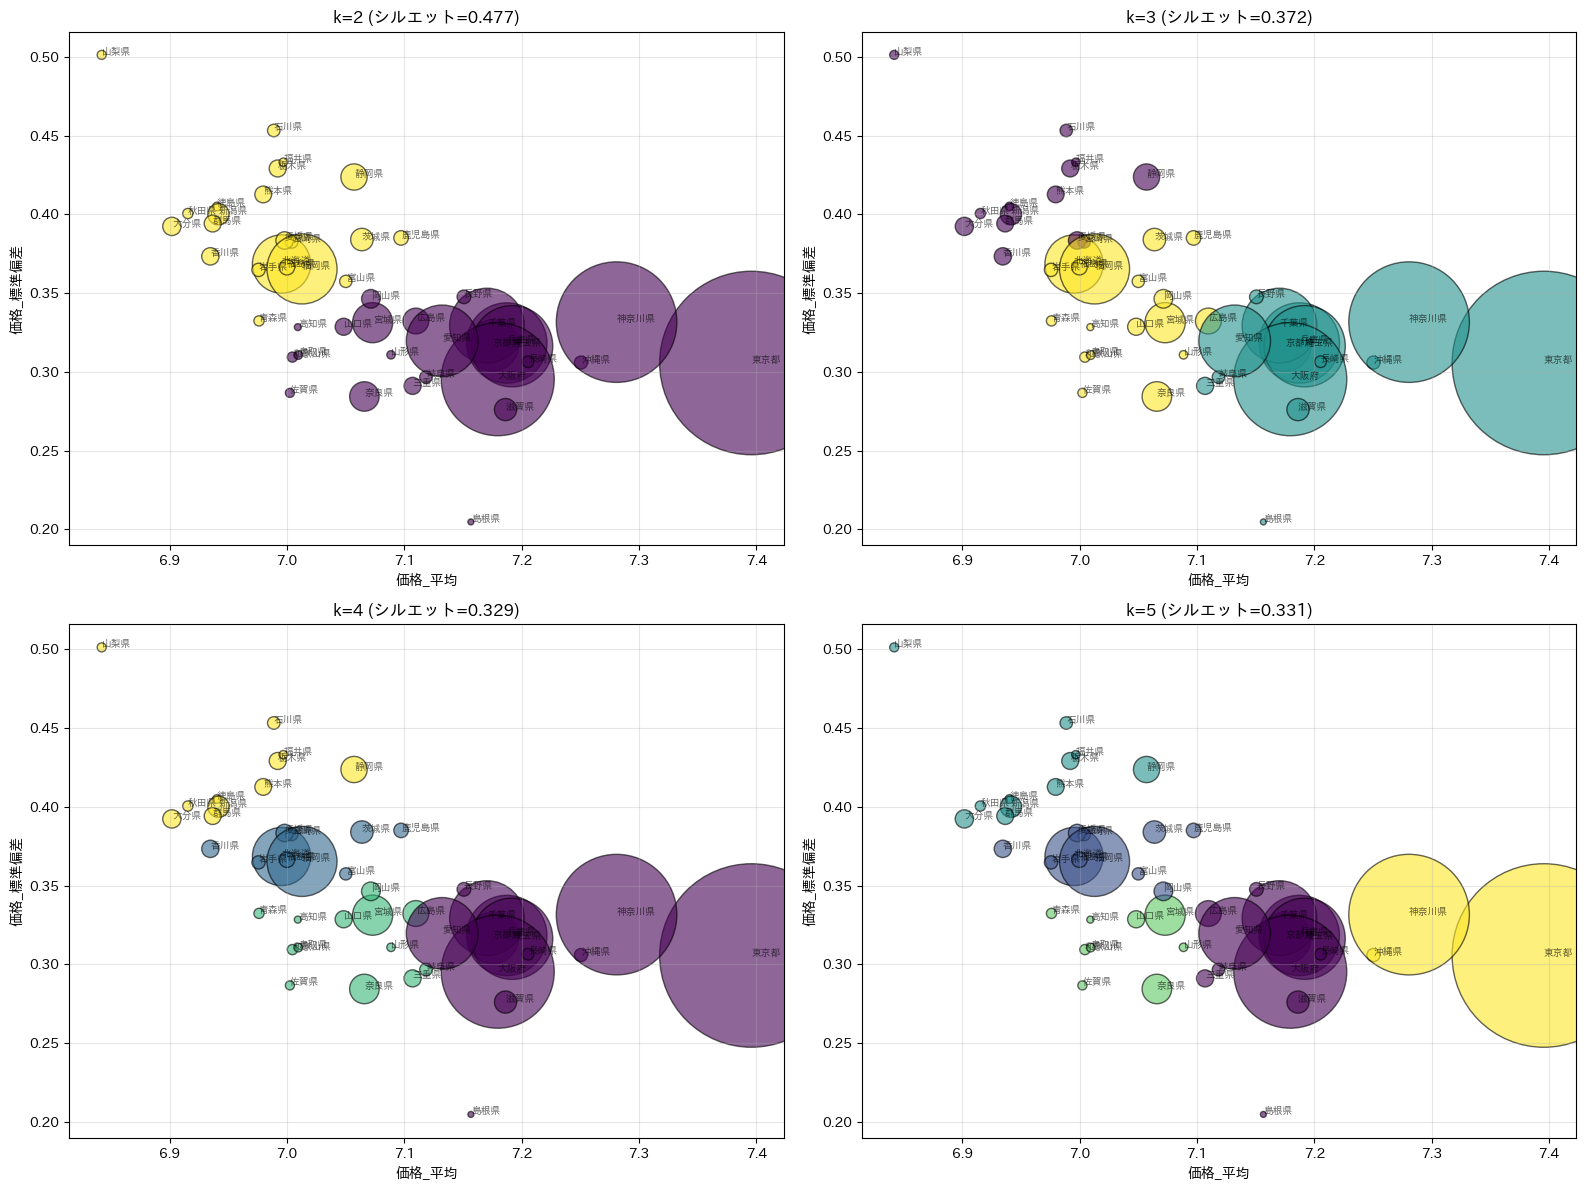

In [36]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# 価格の平均と標準偏差を使用（シンプルで解釈しやすい）
X = prefecture_stats[['価格_平均', '価格_標準偏差']].values
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ===================================
# 1️⃣ エルボー法（曲がり角を探す）
# ===================================
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)  # クラスタ内距離の合計
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# グラフ表示
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# エルボー法
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('クラスタ数', fontsize=12)
axes[0].set_ylabel('Inertia（クラスタ内の距離の合計）', fontsize=12)
axes[0].set_title('エルボー法：曲がり角が最適', fontsize=14)
axes[0].grid(alpha=0.3)
axes[0].axvline(x=3, color='r', linestyle='--', label='k=3', alpha=0.7)
axes[0].legend()

# シルエットスコア
axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('クラスタ数', fontsize=12)
axes[1].set_ylabel('シルエットスコア（高いほど良い）', fontsize=12)
axes[1].set_title('シルエット分析：ピークが最適', fontsize=14)
axes[1].grid(alpha=0.3)
axes[1].axhline(y=max(silhouette_scores), color='r', linestyle='--', alpha=0.3)
axes[1].legend([f'最大値: k={K_range[np.argmax(silhouette_scores)]}'])

plt.tight_layout()
plt.show()

print("="*80)
print("最適クラスタ数の判定結果")
print("="*80)
for k, inertia, sil_score in zip(K_range, inertias, silhouette_scores):
    print(f"k={k}: Inertia={inertia:.2f}, シルエットスコア={sil_score:.3f}")

print("\n" + "="*80)
print("📊 推奨クラスタ数")
print("="*80)
best_k = K_range[np.argmax(silhouette_scores)]
print(f"✓ シルエットスコアが最大: k={best_k} (スコア={max(silhouette_scores):.3f})")
print(f"✓ エルボー法の目視判定: k=2〜3あたりで曲がり角")

# ===================================
# 2️⃣ 各クラスタ数での結果を比較
# ===================================
print("\n" + "="*80)
print("各クラスタ数での都道府県グルーピング")
print("="*80)

for k in [2, 3, 4, 5]:
    print(f"\n【k={k}の場合】")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    prefecture_stats[f'クラスタ_k{k}'] = labels
    
    for cluster in range(k):
        cluster_prefs = prefecture_stats[prefecture_stats[f'クラスタ_k{k}'] == cluster]
        print(f"\nクラスタ {cluster} ({len(cluster_prefs)}都道府県, {cluster_prefs['データ件数'].sum():,}件):")
        print(f"  {', '.join(cluster_prefs['都道府県名'].tolist())}")
        print(f"  価格平均={cluster_prefs['価格_平均'].mean():.2f}, 標準偏差={cluster_prefs['価格_標準偏差'].mean():.2f}")

# ===================================
# 3️⃣ 可視化で比較
# ===================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, k in enumerate([2, 3, 4, 5]):
    ax = axes[idx]
    scatter = ax.scatter(prefecture_stats['価格_平均'], 
                        prefecture_stats['価格_標準偏差'],
                        c=prefecture_stats[f'クラスタ_k{k}'],
                        cmap='viridis',
                        s=prefecture_stats['データ件数']/10,
                        alpha=0.6,
                        edgecolors='black')
    
    for _, row in prefecture_stats.iterrows():
        ax.annotate(row['都道府県名'], 
                   (row['価格_平均'], row['価格_標準偏差']),
                   fontsize=7, alpha=0.6)
    
    ax.set_xlabel('価格_平均')
    ax.set_ylabel('価格_標準偏差')
    ax.set_title(f'k={k} (シルエット={silhouette_scores[idx]:.3f})')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# クラスタリング方法候補（３つ）

都道府県ごとの統計量:
   都道府県名     価格_平均   価格_標準偏差   データ件数  最寄駅：距離（分）_平均   面積（㎡）_平均  建ぺい率（％）_平均  \
0    三重県  7.106916  0.291033    1523      9.884439  73.814839   68.095863   
1    京都府  7.175251  0.316680   13774      8.547844  55.716567   68.386816   
2    佐賀県  7.002321  0.286585     433     14.489607  68.521940   73.094688   
3    兵庫県  7.187249  0.318278   33479      9.107709  66.610263   65.570358   
4    北海道  6.995191  0.368413   17610      8.566780  69.436968   68.784214   
5    千葉県  7.170305  0.329328   28956     11.492299  68.727379   62.908896   
6   和歌山県  7.004451  0.309313     545     11.644037  63.908257   71.743119   
7    埼玉県  7.191769  0.316205   34278     11.190239  63.003092   64.391446   
8    大分県  6.901690  0.392296    1735     14.722767  63.766571   73.025937   
9    大阪府  7.179518  0.295260   66238      7.927957  60.400601   70.509677   
10   奈良県  7.065807  0.284314    4527      9.267948  69.863044   66.008394   
11   宮城県  7.072830  0.331176    8367     10.038843  62.076013   

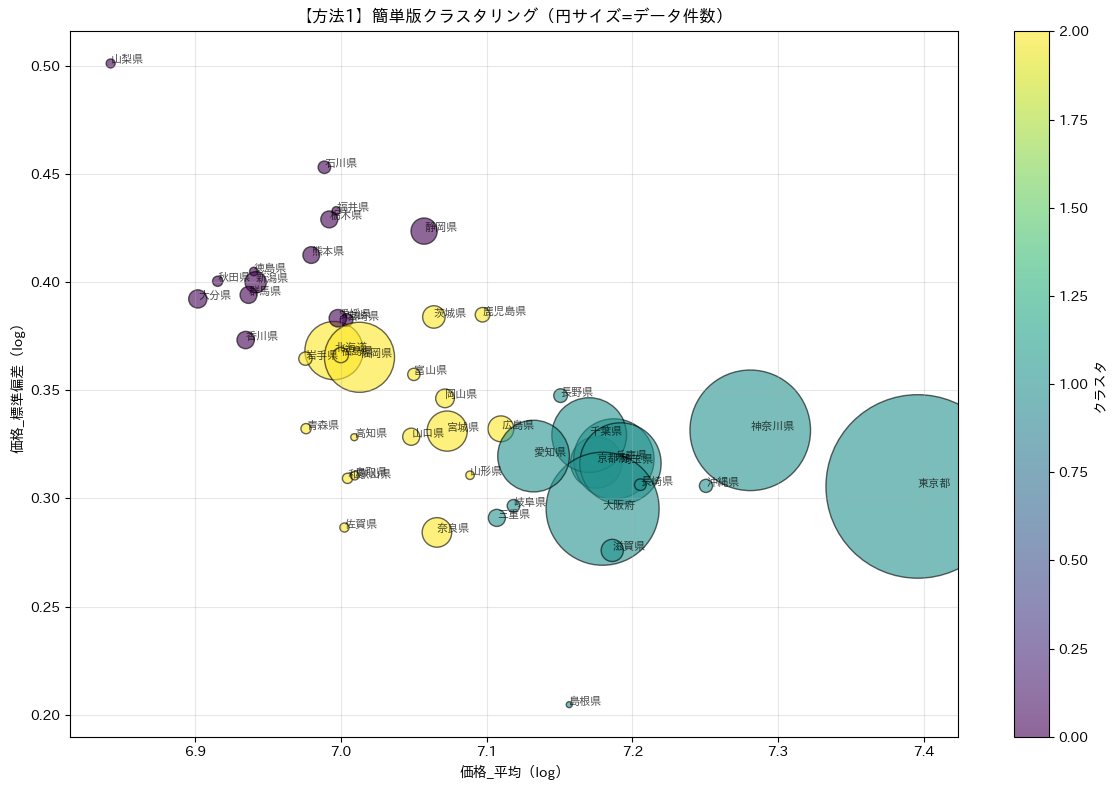


【方法2】データ件数も考慮したクラスタリング

【クラスタ 0】
都道府県: 三重県, 京都府, 佐賀県, 兵庫県, 千葉県, 和歌山県, 埼玉県, 奈良県, 宮城県, 山口県, 山形県, 岐阜県, 岡山県, 島根県, 広島県, 愛知県, 沖縄県, 滋賀県, 長崎県, 長野県, 高知県, 鳥取県
平均データ件数: 7568件
価格平均: 7.11

【クラスタ 1】
都道府県: 北海道, 大分県, 宮崎県, 富山県, 山梨県, 岩手県, 徳島県, 愛媛県, 新潟県, 栃木県, 熊本県, 石川県, 福井県, 福岡県, 福島県, 秋田県, 群馬県, 茨城県, 青森県, 静岡県, 香川県, 鹿児島県
平均データ件数: 3131件
価格平均: 6.98

【クラスタ 2】
都道府県: 大阪府, 東京都, 神奈川県
平均データ件数: 105420件
価格平均: 7.29

【方法3】階層的クラスタリング（デンドログラム）


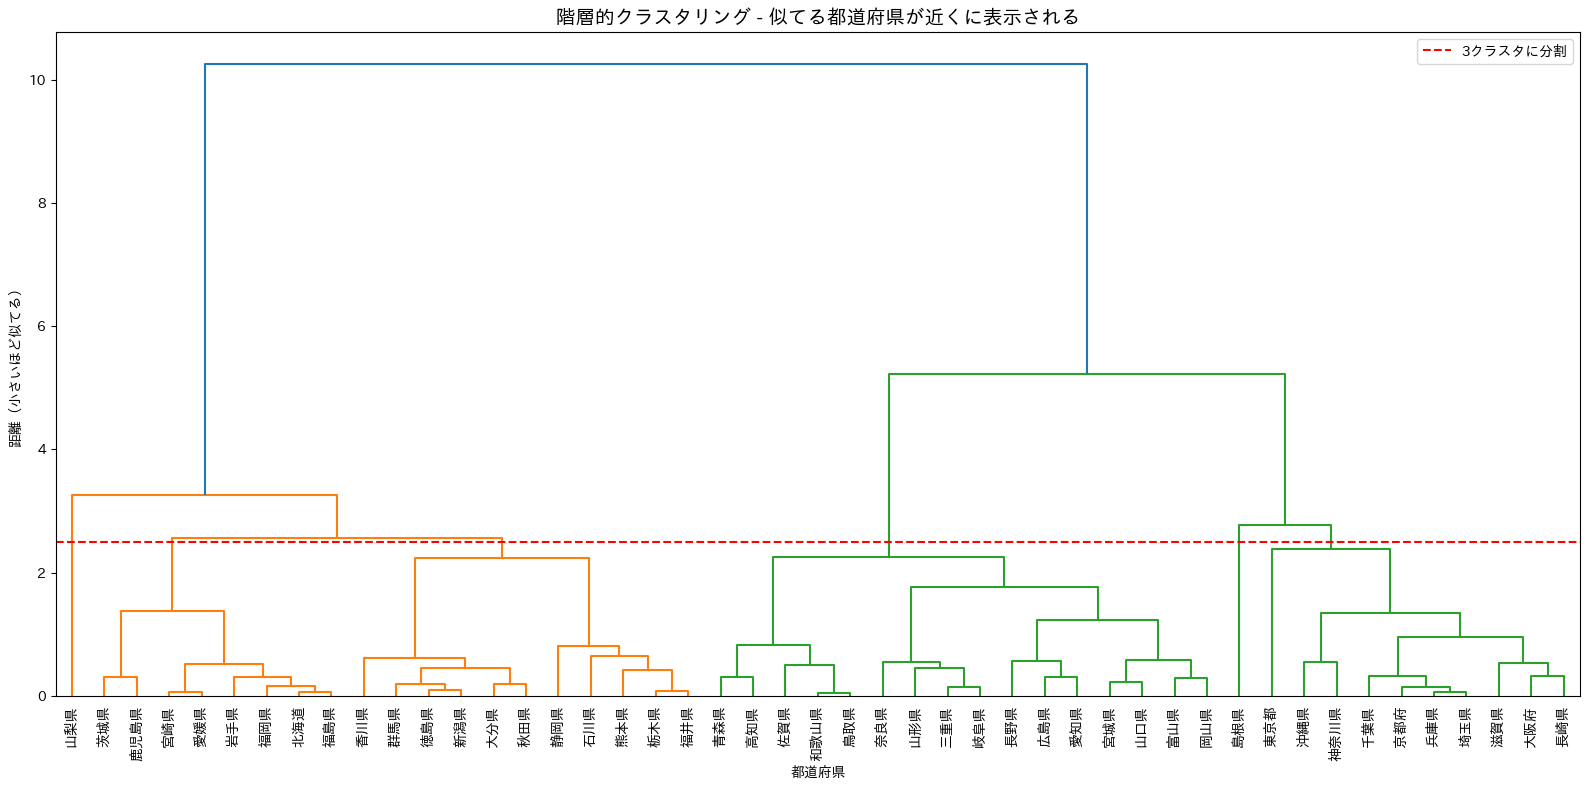


階層的クラスタリングの結果:
クラスタ1: ['北海道', '大分県', '宮崎県', '山梨県', '岩手県', '徳島県', '愛媛県', '新潟県', '栃木県', '熊本県', '石川県', '福井県', '福岡県', '福島県', '秋田県', '群馬県', '茨城県', '静岡県', '香川県', '鹿児島県']
クラスタ2: ['三重県', '佐賀県', '和歌山県', '奈良県', '宮城県', '富山県', '山口県', '山形県', '岐阜県', '岡山県', '広島県', '愛知県', '長野県', '青森県', '高知県', '鳥取県']
クラスタ3: ['京都府', '兵庫県', '千葉県', '埼玉県', '大阪府', '島根県', '東京都', '沖縄県', '滋賀県', '神奈川県', '長崎県']

【方法4】全特徴量（価格・面積・築年数・駅距離など）を使ったクラスタリング

【クラスタ 0】
都道府県: 佐賀県, 和歌山県, 大分県, 富山県, 山形県, 山梨県, 岡山県, 岩手県, 徳島県, 新潟県, 栃木県, 熊本県, 石川県, 福島県, 秋田県, 群馬県, 青森県, 静岡県, 鹿児島県
価格平均: 6.99
面積平均: 62.0㎡
築年数平均: 17.4年
駅距離平均: 13.8分

【クラスタ 1】
都道府県: 三重県, 京都府, 兵庫県, 北海道, 千葉県, 埼玉県, 奈良県, 宮城県, 宮崎県, 山口県, 岐阜県, 島根県, 広島県, 愛媛県, 愛知県, 沖縄県, 滋賀県, 福井県, 福岡県, 茨城県, 長崎県, 長野県, 香川県, 高知県, 鳥取県
価格平均: 7.09
面積平均: 67.0㎡
築年数平均: 16.8年
駅距離平均: 11.0分

【クラスタ 2】
都道府県: 大阪府, 東京都, 神奈川県
価格平均: 7.29
面積平均: 55.6㎡
築年数平均: 17.9年
駅距離平均: 8.6分


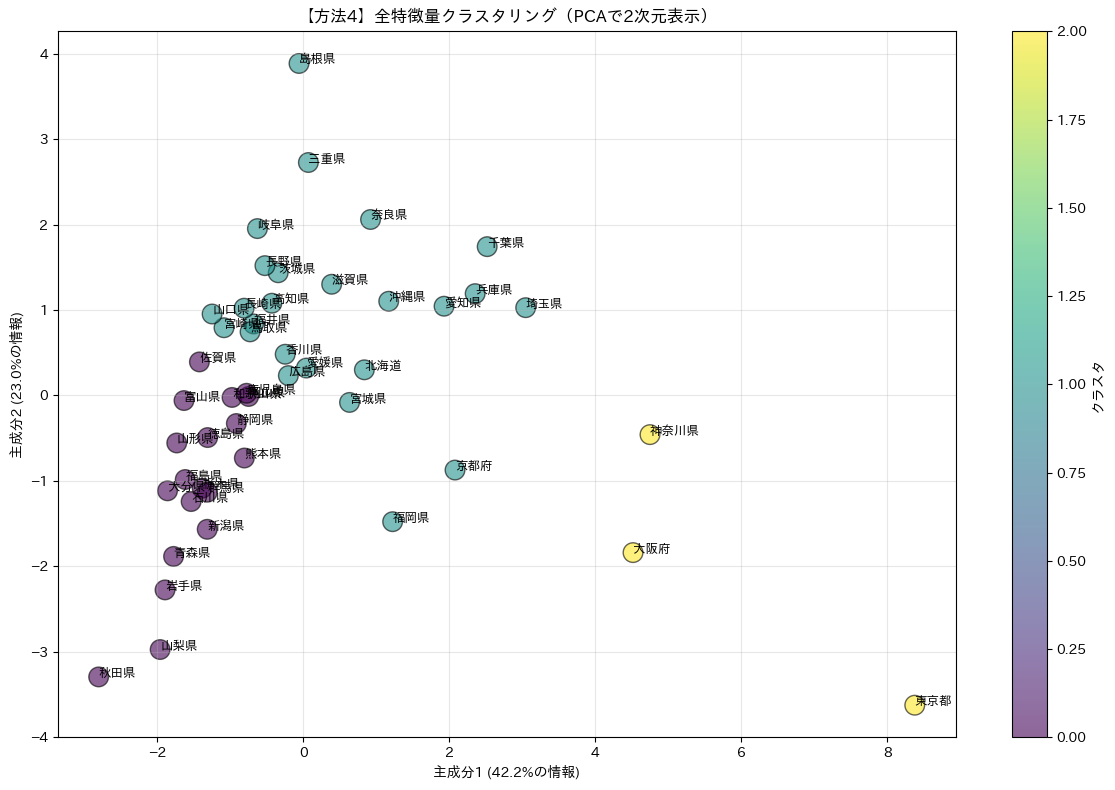


全クラスタリング結果まとめ
都道府県名  データ件数  クラスタ_簡単版  クラスタ_件数考慮  クラスタ_階層  クラスタ_全特徴
  三重県   1523         1          0        2         1
  京都府  13774         1          0        3         1
  佐賀県    433         2          0        2         0
  兵庫県  33479         1          0        3         1
  北海道  17610         2          1        1         1
  千葉県  28956         1          0        3         1
 和歌山県    545         2          0        2         0
  埼玉県  34278         1          0        3         1
  大分県   1735         0          1        1         0
  大阪府  66238         1          2        3         2
  奈良県   4527         2          0        2         1
  宮城県   8367         2          0        2         1
  宮崎県    847         0          1        1         1
  富山県    783         2          1        2         0
  山口県   1518         2          0        2         1
  山形県    371         2          0        2         0
  山梨県    422         0          1        1         0
  岐阜県    824         1         

In [6]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt
import seaborn as sns

# ===================================
# 都道府県ごとの統計量を計算
# ===================================

# 数値特徴量の平均を計算
numeric_cols = [
    '最寄駅：距離（分）', '面積（㎡）', '建ぺい率（％）', '容積率（％）', 
    '取引時点での築年数', '人口密度', '市区町村人口密度'
]

agg_dict = {
    '取引価格（総額）_log': ['mean', 'std', 'count']  # 価格の平均、標準偏差、データ件数
}

# 各数値特徴量の平均を追加
for col in numeric_cols:
    agg_dict[col] = 'mean'

prefecture_stats = df.groupby('都道府県名').agg(agg_dict).reset_index()

# カラム名を整理
prefecture_stats.columns = ['都道府県名', '価格_平均', '価格_標準偏差', 'データ件数'] + \
                           [f'{col}_平均' for col in numeric_cols]

print("都道府県ごとの統計量:")
print(prefecture_stats)
print(f"\n特徴量の数: {len(prefecture_stats.columns)-1}個")

# ===================================
# 1️⃣ 簡単版：価格の平均と標準偏差のみ
# ===================================
print("\n" + "="*80)
print("【方法1】価格の平均と標準偏差だけでクラスタリング（シンプル版）")
print("="*80)

X_simple = prefecture_stats[['価格_平均', '価格_標準偏差']].values
scaler = StandardScaler()
X_simple_scaled = scaler.fit_transform(X_simple)

kmeans_simple = KMeans(n_clusters=3, random_state=42, n_init=10)
prefecture_stats['クラスタ_簡単版'] = kmeans_simple.fit_predict(X_simple_scaled)

for cluster in range(3):
    cluster_prefs = prefecture_stats[prefecture_stats['クラスタ_簡単版'] == cluster]
    print(f"\n【クラスタ {cluster}】 ({len(cluster_prefs)}都道府県)")
    print(f"都道府県: {', '.join(cluster_prefs['都道府県名'].tolist())}")
    print(f"価格平均: {cluster_prefs['価格_平均'].mean():.2f}")
    print(f"価格標準偏差: {cluster_prefs['価格_標準偏差'].mean():.2f}")
    print(f"データ件数合計: {cluster_prefs['データ件数'].sum():,}件")

plt.figure(figsize=(12, 8))
scatter = plt.scatter(prefecture_stats['価格_平均'], 
                     prefecture_stats['価格_標準偏差'], 
                     c=prefecture_stats['クラスタ_簡単版'], 
                     cmap='viridis', 
                     s=prefecture_stats['データ件数']/10,
                     alpha=0.6,
                     edgecolors='black')
for idx, row in prefecture_stats.iterrows():
    plt.annotate(row['都道府県名'], 
                (row['価格_平均'], row['価格_標準偏差']),
                fontsize=8, alpha=0.7)
plt.xlabel('価格_平均（log）')
plt.ylabel('価格_標準偏差（log）')
plt.title('【方法1】簡単版クラスタリング（円サイズ=データ件数）')
plt.colorbar(scatter, label='クラスタ')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ===================================
# 2️⃣ データ件数も考慮版
# ===================================
print("\n" + "="*80)
print("【方法2】データ件数も考慮したクラスタリング")
print("="*80)

X_with_count = prefecture_stats[['価格_平均', '価格_標準偏差', 'データ件数']].values
X_with_count_scaled = StandardScaler().fit_transform(X_with_count)

kmeans_count = KMeans(n_clusters=3, random_state=42, n_init=10)
prefecture_stats['クラスタ_件数考慮'] = kmeans_count.fit_predict(X_with_count_scaled)

for cluster in range(3):
    cluster_prefs = prefecture_stats[prefecture_stats['クラスタ_件数考慮'] == cluster]
    print(f"\n【クラスタ {cluster}】")
    print(f"都道府県: {', '.join(cluster_prefs['都道府県名'].tolist())}")
    print(f"平均データ件数: {cluster_prefs['データ件数'].mean():.0f}件")
    print(f"価格平均: {cluster_prefs['価格_平均'].mean():.2f}")

# ===================================
# 3️⃣ 階層的クラスタリング（デンドログラム）
# ===================================
print("\n" + "="*80)
print("【方法3】階層的クラスタリング（デンドログラム）")
print("="*80)

linkage_matrix = linkage(X_simple_scaled, method='ward')

plt.figure(figsize=(16, 8))
dendrogram(linkage_matrix, 
           labels=prefecture_stats['都道府県名'].values,
           leaf_font_size=10)
plt.title('階層的クラスタリング - 似てる都道府県が近くに表示される', fontsize=14)
plt.xlabel('都道府県')
plt.ylabel('距離（小さいほど似てる）')
plt.xticks(rotation=90)
plt.axhline(y=2.5, color='r', linestyle='--', label='3クラスタに分割')
plt.legend()
plt.tight_layout()
plt.show()

prefecture_stats['クラスタ_階層'] = fcluster(linkage_matrix, 3, criterion='maxclust')

print("\n階層的クラスタリングの結果:")
for cluster in range(1, 4):
    prefs = prefecture_stats[prefecture_stats['クラスタ_階層'] == cluster]['都道府県名'].tolist()
    print(f"クラスタ{cluster}: {prefs}")

# ===================================
# 4️⃣ 全特徴量を使った版
# ===================================
print("\n" + "="*80)
print("【方法4】全特徴量（価格・面積・築年数・駅距離など）を使ったクラスタリング")
print("="*80)

feature_cols = ['価格_平均', '価格_標準偏差', 'データ件数'] + \
               [f'{col}_平均' for col in numeric_cols]

X_all = prefecture_stats[feature_cols].values
X_all_scaled = StandardScaler().fit_transform(X_all)

kmeans_all = KMeans(n_clusters=3, random_state=42, n_init=10)
prefecture_stats['クラスタ_全特徴'] = kmeans_all.fit_predict(X_all_scaled)

for cluster in range(3):
    cluster_prefs = prefecture_stats[prefecture_stats['クラスタ_全特徴'] == cluster]
    print(f"\n【クラスタ {cluster}】")
    print(f"都道府県: {', '.join(cluster_prefs['都道府県名'].tolist())}")
    print(f"価格平均: {cluster_prefs['価格_平均'].mean():.2f}")
    print(f"面積平均: {cluster_prefs['面積（㎡）_平均'].mean():.1f}㎡")
    print(f"築年数平均: {cluster_prefs['取引時点での築年数_平均'].mean():.1f}年")
    print(f"駅距離平均: {cluster_prefs['最寄駅：距離（分）_平均'].mean():.1f}分")

# PCAで2次元に圧縮して可視化
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=prefecture_stats['クラスタ_全特徴'],
                     cmap='viridis',
                     s=200,
                     alpha=0.6,
                     edgecolors='black')
for idx, row in prefecture_stats.iterrows():
    plt.annotate(row['都道府県名'], 
                (X_pca[idx, 0], X_pca[idx, 1]),
                fontsize=9)
plt.xlabel(f'主成分1 ({pca.explained_variance_ratio_[0]*100:.1f}%の情報)')
plt.ylabel(f'主成分2 ({pca.explained_variance_ratio_[1]*100:.1f}%の情報)')
plt.title('【方法4】全特徴量クラスタリング（PCAで2次元表示）')
plt.colorbar(scatter, label='クラスタ')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ===================================
# 最終結果まとめ
# ===================================
print("\n" + "="*80)
print("全クラスタリング結果まとめ")
print("="*80)
result_summary = prefecture_stats[['都道府県名', 'データ件数', 'クラスタ_簡単版', 
                                   'クラスタ_件数考慮', 'クラスタ_階層', 'クラスタ_全特徴']]
print(result_summary.to_string(index=False))

# データ件数と価格の相関関係について

データ件数と価格の関係

データ件数 vs 価格平均:
  相関係数: 0.635 (p値=0.0000)
  → 強い正の相関

データ件数 vs 価格標準偏差:
  相関係数: -0.217 (p値=0.1434)


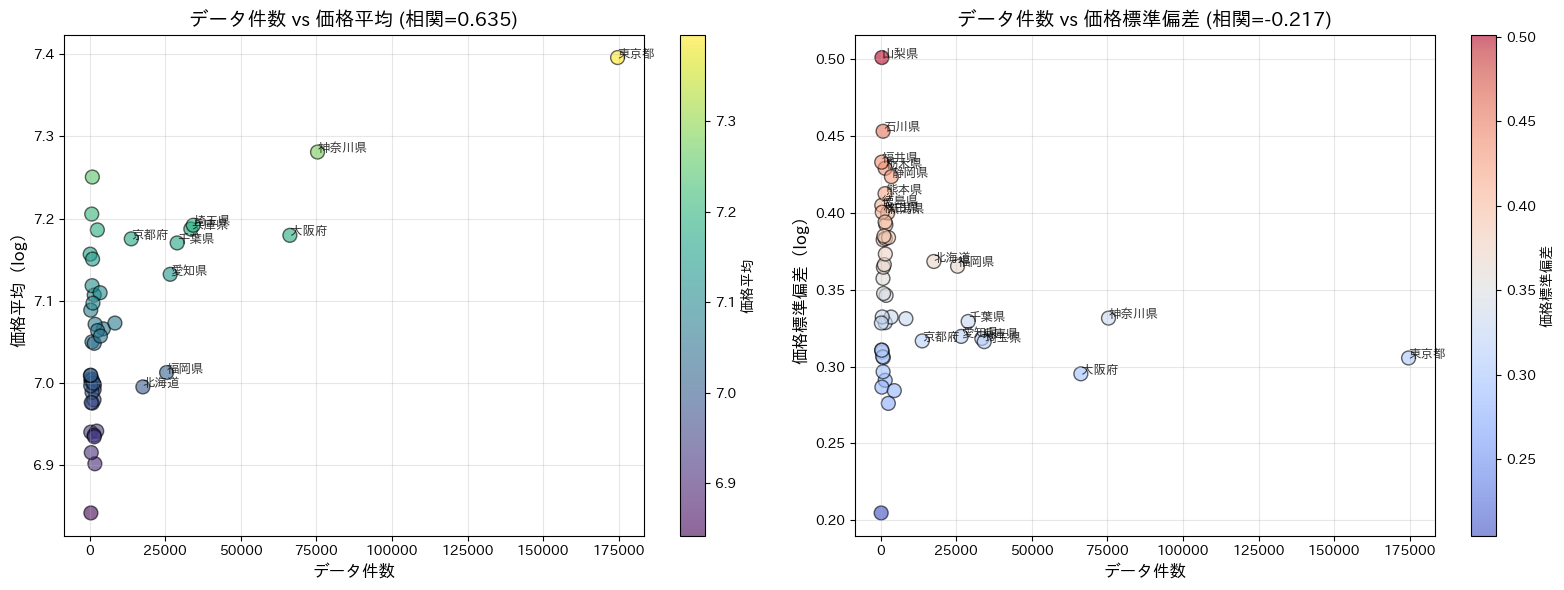


データ件数TOP10の都道府県
都道府県名  データ件数    価格_平均  価格_標準偏差
  東京都 174637 7.395754 0.305572
 神奈川県  75385 7.280832 0.331528
  大阪府  66238 7.179518 0.295260
  埼玉県  34278 7.191769 0.316205
  兵庫県  33479 7.187249 0.318278
  千葉県  28956 7.170305 0.329328
  愛知県  26655 7.132122 0.319618
  福岡県  25458 7.012647 0.365307
  北海道  17610 6.995191 0.368413
  京都府  13774 7.175251 0.316680

価格平均TOP10の都道府県
都道府県名  データ件数    価格_平均  価格_標準偏差
  東京都 174637 7.395754 0.305572
 神奈川県  75385 7.280832 0.331528
  沖縄県    900 7.250448 0.305843
  長崎県    703 7.205405 0.306382
  埼玉県  34278 7.191769 0.316205
  兵庫県  33479 7.187249 0.318278
  滋賀県   2556 7.186135 0.275992
  大阪府  66238 7.179518 0.295260
  京都府  13774 7.175251 0.316680
  千葉県  28956 7.170305 0.329328

💡 結論
✓ データ件数が多い都道府県は価格が高い傾向がある
  → 都市部ほど取引が多く、価格も高い（当然の結果）

しかし、クラスタリングは「件数」だけでなく:
  - 価格の平均
  - 価格のばらつき（標準偏差）
の組み合わせで分けてるから、単純な「件数と価格」だけの話ではない


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr, spearmanr

# ===================================
# 相関分析
# ===================================
print("="*80)
print("データ件数と価格の関係")
print("="*80)

# 相関係数
corr_mean, p_mean = pearsonr(prefecture_stats['データ件数'], prefecture_stats['価格_平均'])
corr_std, p_std = pearsonr(prefecture_stats['データ件数'], prefecture_stats['価格_標準偏差'])

print(f"\nデータ件数 vs 価格平均:")
print(f"  相関係数: {corr_mean:.3f} (p値={p_mean:.4f})")
print(f"  → {'強い正の相関' if corr_mean > 0.5 else '中程度の相関' if corr_mean > 0.3 else '弱い相関'}")

print(f"\nデータ件数 vs 価格標準偏差:")
print(f"  相関係数: {corr_std:.3f} (p値={p_std:.4f})")

# ===================================
# 散布図で視覚的に確認
# ===================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. データ件数 vs 価格平均
ax1 = axes[0]
scatter = ax1.scatter(prefecture_stats['データ件数'], 
                     prefecture_stats['価格_平均'],
                     s=100,
                     alpha=0.6,
                     c=prefecture_stats['価格_平均'],
                     cmap='viridis',
                     edgecolors='black')

# 特定の都道府県をラベル表示
for _, row in prefecture_stats.iterrows():
    if row['データ件数'] > 10000 or row['価格_平均'] > 7.3:  # 目立つところだけ
        ax1.annotate(row['都道府県名'], 
                    (row['データ件数'], row['価格_平均']),
                    fontsize=9, alpha=0.8)

ax1.set_xlabel('データ件数', fontsize=12)
ax1.set_ylabel('価格平均（log）', fontsize=12)
ax1.set_title(f'データ件数 vs 価格平均 (相関={corr_mean:.3f})', fontsize=14)
ax1.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax1, label='価格平均')

# 2. データ件数 vs 価格標準偏差
ax2 = axes[1]
scatter2 = ax2.scatter(prefecture_stats['データ件数'], 
                      prefecture_stats['価格_標準偏差'],
                      s=100,
                      alpha=0.6,
                      c=prefecture_stats['価格_標準偏差'],
                      cmap='coolwarm',
                      edgecolors='black')

for _, row in prefecture_stats.iterrows():
    if row['データ件数'] > 10000 or row['価格_標準偏差'] > 0.4:
        ax2.annotate(row['都道府県名'], 
                    (row['データ件数'], row['価格_標準偏差']),
                    fontsize=9, alpha=0.8)

ax2.set_xlabel('データ件数', fontsize=12)
ax2.set_ylabel('価格標準偏差（log）', fontsize=12)
ax2.set_title(f'データ件数 vs 価格標準偏差 (相関={corr_std:.3f})', fontsize=14)
ax2.grid(alpha=0.3)
plt.colorbar(scatter2, ax=ax2, label='価格標準偏差')

plt.tight_layout()
plt.show()

# ===================================
# 詳細分析：データ件数の多い都道府県
# ===================================
print("\n" + "="*80)
print("データ件数TOP10の都道府県")
print("="*80)
top10 = prefecture_stats.nlargest(10, 'データ件数')[['都道府県名', 'データ件数', '価格_平均', '価格_標準偏差']]
print(top10.to_string(index=False))

print("\n" + "="*80)
print("価格平均TOP10の都道府県")
print("="*80)
top10_price = prefecture_stats.nlargest(10, '価格_平均')[['都道府県名', 'データ件数', '価格_平均', '価格_標準偏差']]
print(top10_price.to_string(index=False))

# ===================================
# 結論
# ===================================
print("\n" + "="*80)
print("💡 結論")
print("="*80)
if corr_mean > 0.5:
    print("✓ データ件数が多い都道府県は価格が高い傾向がある")
    print("  → 都市部ほど取引が多く、価格も高い（当然の結果）")
elif corr_mean > 0.3:
    print("✓ データ件数と価格には中程度の相関がある")
    print("  → 都市部は取引が多く価格も高いが、例外もある")
else:
    print("✓ データ件数と価格の相関は弱い")
    print("  → 単純に「件数多い=高い」ではない")

print(f"\nしかし、クラスタリングは「件数」だけでなく:")
print("  - 価格の平均")
print("  - 価格のばらつき（標準偏差）")
print("の組み合わせで分けてるから、単純な「件数と価格」だけの話ではない")

#　クラスタリング（２分割、都道府県ベース）

In [39]:
# 都道府県ごとの統計量を計算

numeric_cols = [
    '最寄駅：距離（分）', '面積（㎡）', '建ぺい率（％）', '容積率（％）', 
    '取引時点での築年数', '人口密度', '市区町村人口密度'
]

agg_dict = {'取引価格（総額）_log': ['mean', 'std', 'count']}
for col in numeric_cols:
    agg_dict[col] = 'mean'

prefecture_stats = df.groupby('都道府県名').agg(agg_dict).reset_index()
prefecture_stats.columns = ['都道府県名', '価格_平均', '価格_標準偏差', 'データ件数'] + \
                           [f'{col}_平均' for col in numeric_cols]

In [41]:
# 複数のクラスタリング方法を実行

print("\n" + "="*80)
print("複数のクラスタリング方法を実行")
print("="*80)

# 1. 簡単版（価格の平均と標準偏差のみ）
print("\n1. クラスタ_簡単版")
X_simple = prefecture_stats[['価格_平均', '価格_標準偏差']].values
scaler_simple = StandardScaler()
X_simple_scaled = scaler_simple.fit_transform(X_simple)
kmeans_simple = KMeans(n_clusters=3, random_state=42, n_init=10)
prefecture_stats['クラスタ_簡単版'] = kmeans_simple.fit_predict(X_simple_scaled)

# 2. 件数考慮版（価格 + データ件数）
print("2. クラスタ_件数考慮")
X_count = prefecture_stats[['価格_平均', '価格_標準偏差', 'データ件数']].values
scaler_count = StandardScaler()
X_count_scaled = scaler_count.fit_transform(X_count)
kmeans_count = KMeans(n_clusters=3, random_state=42, n_init=10)
prefecture_stats['クラスタ_件数考慮'] = kmeans_count.fit_predict(X_count_scaled)

# 3. 階層的クラスタリング
print("3. クラスタ_階層")
linkage_matrix = linkage(X_simple_scaled, method='ward')
prefecture_stats['クラスタ_階層'] = fcluster(linkage_matrix, 3, criterion='maxclust')

# 4. 全特徴量版
print("4. クラスタ_全特徴")
feature_cols = ['価格_平均', '価格_標準偏差', 'データ件数'] + [f'{col}_平均' for col in numeric_cols]
X_all = prefecture_stats[feature_cols].values
scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(X_all)
kmeans_all = KMeans(n_clusters=3, random_state=42, n_init=10)
prefecture_stats['クラスタ_全特徴'] = kmeans_all.fit_predict(X_all_scaled)

# ===================================
# 各クラスタリング結果の概要を表示
# ===================================
print("\n" + "="*80)
print("各クラスタリング方法の概要")
print("="*80)

cluster_methods = ['クラスタ_簡単版', 'クラスタ_件数考慮', 'クラスタ_階層', 'クラスタ_全特徴']

for method in cluster_methods:
    print(f"\n【{method}】")
    for cluster in sorted(prefecture_stats[method].unique()):
        cluster_prefs = prefecture_stats[prefecture_stats[method] == cluster]
        print(f"  クラスタ {cluster}: {len(cluster_prefs)}都道府県, {cluster_prefs['データ件数'].sum():,}件")



複数のクラスタリング方法を実行

1. クラスタ_簡単版
2. クラスタ_件数考慮
3. クラスタ_階層
4. クラスタ_全特徴

各クラスタリング方法の概要

【クラスタ_簡単版】
  クラスタ 0: 14都道府県, 18,626件
  クラスタ 1: 15都道府県, 461,074件
  クラスタ 2: 18都道府県, 71,945件

【クラスタ_件数考慮】
  クラスタ 0: 22都道府県, 166,503件
  クラスタ 1: 22都道府県, 68,882件
  クラスタ 2: 3都道府県, 316,260件

【クラスタ_階層】
  クラスタ 1: 20都道府県, 67,559件
  クラスタ 2: 16都道府県, 52,994件
  クラスタ 3: 11都道府県, 431,092件

【クラスタ_全特徴】
  クラスタ 0: 19都道府県, 21,999件
  クラスタ 1: 25都道府県, 213,386件
  クラスタ 2: 3都道府県, 316,260件



可視化


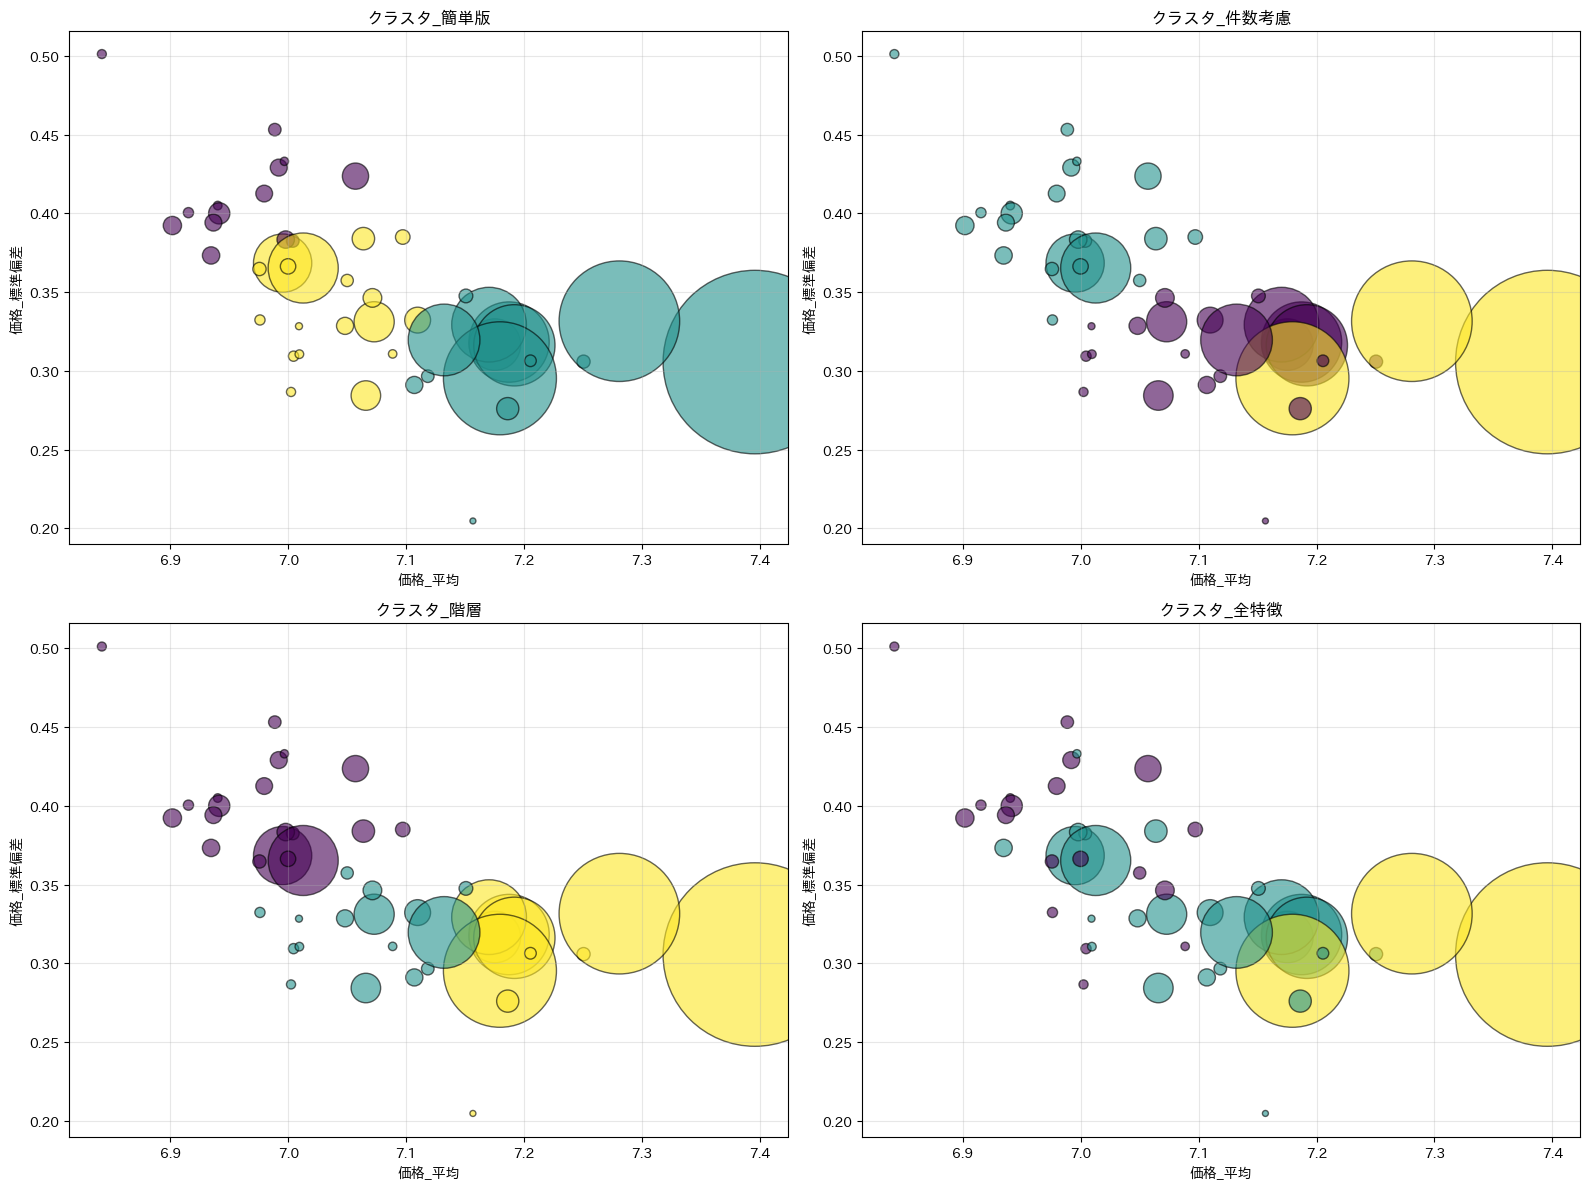

In [42]:
# ===================================
# 可視化
# ===================================
print("\n" + "="*80)
print("可視化")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, method in enumerate(cluster_methods):
    ax = axes[idx]
    scatter = ax.scatter(prefecture_stats['価格_平均'], 
                        prefecture_stats['価格_標準偏差'],
                        c=prefecture_stats[method],
                        cmap='viridis',
                        s=prefecture_stats['データ件数']/10,
                        alpha=0.6,
                        edgecolors='black')
    
    ax.set_xlabel('価格_平均')
    ax.set_ylabel('価格_標準偏差')
    ax.set_title(method)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:

# ===================================
# 全パターンを保存
# ===================================
print("\n" + "="*80)
print("クラスタリング結果を保存")
print("="*80)

save_cols = ['都道府県名'] + cluster_methods
cluster_all_df = prefecture_stats[save_cols].copy()

cluster_all_df.to_csv('prefecture_cluster_all_methods.csv', index=False, encoding='utf-8-sig')
print("\n✓ 全クラスタリング結果を保存しました: prefecture_cluster_all_methods.csv")
print(f"  保存したクラスタリング方法: {len(cluster_methods)}種類")
print(f"  {', '.join(cluster_methods)}")

print("\n保存内容の確認:")
print(cluster_all_df.head(10))



クラスタリング結果を保存

✓ 全クラスタリング結果を保存しました: prefecture_cluster_all_methods.csv
  保存したクラスタリング方法: 4種類
  クラスタ_簡単版, クラスタ_件数考慮, クラスタ_階層, クラスタ_全特徴

保存内容の確認:
  都道府県名  クラスタ_簡単版  クラスタ_件数考慮  クラスタ_階層  クラスタ_全特徴
0   三重県         1          0        2         1
1   京都府         1          0        3         1
2   佐賀県         2          0        2         0
3   兵庫県         1          0        3         1
4   北海道         2          1        1         1
5   千葉県         1          0        3         1
6  和歌山県         2          0        2         0
7   埼玉県         1          0        3         1
8   大分県         0          1        1         0
9   大阪府         1          2        3         2
